# 11 — Invariance Analysis: SO(3) Rotation & Translation Robustness

From `SUMMER_PLAN.md`'s "Full-Body Rotation and Translation Test": since the
models are not built with true SE(3) equivariance, this notebook tests
empirically whether prediction quality is stable under random rotations and
translations of the input geometry. If stable, that's a strong argument
against the complexity cost of a Tier-5 equivariant architecture; if not,
it motivates coordinate augmentation during training and/or that investment.

**This is an evaluation-only notebook — no training happens here.** It
reuses the four checkpoints from notebook 10 (Sweep C: `{distance,
attention} x {features on, features off}`, each using its architecture's
Sweep B winning aggregation) and evaluates them under transformed inputs.
Positioned right after notebook 10 rather than at the end of the study
because a failure here would call the entire non-equivariant architecture
into question — worth knowing before sinking more compute into later sweeps.

## Why this might already be a non-issue for half the models

Every `MessageLayer` edge feature is an RBF encoding of a pairwise
*distance*, and `AtomEncoder` uses only categorical atom/residue/bond-count
features — none of these change under a rigid rotation+translation of the
whole structure. The **one** exception is `QueryEncoder`'s optional
`normal` feature: it's fed as raw x/y/z components into an MLP with no
equivariant handling, so it *does* change under rotation.

That means the `features off` checkpoints (no `normal`, no `curvature`)
should be **exactly** invariant by construction — not an empirical
discovery, a mathematical consequence of the input feature set. The
`features on` checkpoints are the genuinely open question. Section 2 below
verifies this reasoning numerically on a real cached graph before running
the full sweep, so the rest of the notebook isn't just trusting the
argument.

## Method

For each checkpoint, each of several transform types, and multiple random
draws per type, per test protein:
1. Apply the transform to the cached graph's `atom.pos` / `query.pos` (and
   rotate `query.normal` if present — directions rotate but don't
   translate).
2. Recompute the `radial`/`aq`/`qq` edges (kNN + RBF) from the transformed
   positions using the same functions `graph_builder.py` uses at graph-build
   time — not just re-using the cached edges, so this is a genuine
   re-derivation of the graph representation, not an assumption that it's
   unchanged. Bond edges are left untouched (bond distances are invariant;
   recomputing them would just reproduce the same values).
3. Run the frozen model on both the original and transformed graph, compare
   predictions directly — this is the actual invariance metric, independent
   of ground-truth accuracy.

**Transform types:** `translation` (negative control — nothing in the
feature set is position-absolute, so this should show exactly zero effect
regardless of model; a failure here would indicate a bug, not a real
finding), `rotation` (the real test), `rotation+translation` (realistic
worst case, both applied together).

## 1. Setup: imports and rigid-transform helpers

In [1]:
import copy
import json
import sys
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.spatial.transform import Rotation

sys.path.insert(0, str(Path("../..").resolve()))

from src.analysis.embedding_analysis import load_model_frozen, _load_graph
from src.data.dataset import load_split_manifest
from src.utils.config import get_data_root

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = get_data_root()
print(f"DEVICE: {DEVICE}")


def show_png_grid(runs, filename, title, ncols=2):
    """Display saved PNG plots from each run's plot_dir in a grid.

    analyze_model.py saves plots with a model-name prefix (e.g.
    'attention_parity_hexbin.png', 'distance_parity_hexbin.png'), so the
    actual filename is built per-run from run['model_type'] — passing a
    bare 'parity_hexbin.png' here is deliberate, the prefix is added below.
    """
    def _path(run):
        return run["plot_dir"] / f"{run['model_type']}_{filename}"

    available = [r for r in runs if _path(r).exists()]
    if not available:
        print(f"No '*_{filename}' plots found. Run analyze_model.py --save-plots first.")
        return
    nrows = (len(available) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    for ax, run in zip(axes, available):
        ax.imshow(mpimg.imread(_path(run)))
        ax.set_title(run["label"], fontsize=11)
        ax.axis("off")
    for ax in axes[len(available):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

/home/student/miniconda3/envs/pyg_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE: cuda


In [2]:
def _bond_set_from_edge_index(edge_index: torch.Tensor) -> set[tuple[int, int]]:
    """Reconstruct the undirected (min,max) bond-pair set from the cached bond edge_index."""
    src = edge_index[0].tolist()
    dst = edge_index[1].tolist()
    return {(min(i, j), max(i, j)) for i, j in zip(src, dst)}


def apply_rigid_transform(data, R: np.ndarray, t: np.ndarray):
    """
    Return a NEW HeteroData with atom/query positions rigidly transformed
    (x -> x @ R.T + t).

    Edge features are NOT recomputed — pairwise distances are invariant under
    rigid transforms (||Rx+t - Ry-t|| = ||x-y||), so the cached RBF encodings
    and kNN topology are identical after the transform. Only positions and
    normals (if present) are updated.

    query.normal is rotated but not translated (it's a unit direction, not a
    position). curvature is a scalar invariant and is left untouched.

    `data` must be CPU-resident.
    """
    new_data = copy.deepcopy(data)

    atom_xyz  = data["atom"].pos.numpy()
    query_xyz = data["query"].pos.numpy()

    new_data["atom"].pos  = torch.tensor((atom_xyz  @ R.T) + t, dtype=torch.float)
    new_data["query"].pos = torch.tensor((query_xyz @ R.T) + t, dtype=torch.float)

    if hasattr(data["query"], "normal"):
        normal     = data["query"].normal.numpy()
        new_normal = normal @ R.T
        new_normal = new_normal / np.linalg.norm(new_normal, axis=-1, keepdims=True)
        new_data["query"].normal = torch.tensor(new_normal, dtype=torch.float)

    return new_data


def random_rotation(rng: np.random.Generator) -> np.ndarray:
    """Uniform random SO(3) rotation matrix."""
    return Rotation.random(random_state=rng).as_matrix()


def random_translation(rng: np.random.Generator, scale: float = 50.0) -> np.ndarray:
    """Random translation vector, uniform in [-scale, scale] per axis (Å)."""
    return rng.uniform(-scale, scale, size=3)


def get_transform(transform_type: str, rng: np.random.Generator):
    """Return (R, t) for a named transform type. 'none' -> identity."""
    I3 = np.eye(3)
    zero = np.zeros(3)
    if transform_type == "none":
        return I3, zero
    if transform_type == "translation":
        return I3, random_translation(rng)
    if transform_type == "rotation":
        return random_rotation(rng), zero
    if transform_type == "rotation+translation":
        return random_rotation(rng), random_translation(rng)
    raise ValueError(f"unknown transform_type: {transform_type}")


@torch.no_grad()
def predict_esp(model, data, esp_mean: float, esp_std: float, device) -> np.ndarray:
    """Forward pass + denormalize to raw kT/e."""
    data_on_device = data.clone().to(device)
    pred_norm = model(data_on_device)
    pred_raw  = pred_norm * esp_std + esp_mean
    return pred_raw.cpu().numpy()


print("Helpers defined.")

Helpers defined.


## 2. Sanity check: verify the invariance argument numerically

Before running the full sweep, confirm on one real protein that (a) the
radial/aq/qq RBF edge features really are numerically invariant under a
random rigid transform, (b) bond edges are untouched, and (c) normal
vectors (when present) genuinely do change. If any of this doesn't hold,
the rest of the notebook's results aren't trustworthy.

In [3]:
_, _, _sanity_test_ids = load_split_manifest(DATA_ROOT)
SANITY_PID = _sanity_test_ids[0]

_sanity_data = _load_graph(SANITY_PID, DATA_ROOT)
print(f"Sanity-check protein: {SANITY_PID}")
print(f"  atom nodes: {_sanity_data['atom'].pos.shape[0]}   query nodes: {_sanity_data['query'].pos.shape[0]}")
print(f"  has normal: {hasattr(_sanity_data['query'], 'normal')}")
print(f"  has curvature: {hasattr(_sanity_data['query'], 'curvature')}")

_rng = np.random.default_rng(42)
_R, _t = get_transform("rotation+translation", _rng)
_transformed = apply_rigid_transform(_sanity_data, _R, _t)

print("\n--- Edge count check (should match exactly) ---")
for et in [("atom", "radial", "atom"), ("atom", "aq", "query"), ("query", "qq", "query")]:
    n_orig = _sanity_data[et].edge_index.shape[1]
    n_new  = _transformed[et].edge_index.shape[1]
    print(f"  {et}: orig={n_orig}  transformed={n_new}  match={n_orig == n_new}")

print("\n--- RBF invariance check (radial edges — should be ~0 diff) ---")
_orig_rbf = _sanity_data["atom", "radial", "atom"].edge_attr.numpy()
_new_rbf  = _transformed["atom", "radial", "atom"].edge_attr.numpy()
if _orig_rbf.shape == _new_rbf.shape:
    _diff = np.abs(_orig_rbf - _new_rbf)
    print(f"  max abs diff: {_diff.max():.2e}   mean abs diff: {_diff.mean():.2e}")
else:
    print(f"  SHAPE MISMATCH — kNN topology changed under rotation (rare tie-break flip)")

print("\n--- Bond edge invariance check (should be identical) ---")
_bond_same = torch.equal(_sanity_data["atom", "bond", "atom"].edge_attr,
                          _transformed["atom", "bond", "atom"].edge_attr)
print(f"  bond edge_attr identical: {_bond_same}")

if hasattr(_sanity_data["query"], "normal"):
    print("\n--- Normal vector check (should differ — normals rotate) ---")
    _n_orig = _sanity_data["query"].normal.numpy()
    _n_new  = _transformed["query"].normal.numpy()
    print(f"  max abs diff: {np.abs(_n_orig - _n_new).max():.4f}")
else:
    print("\n(no normal feature on this cached graph)")

Sanity-check protein: AF-O69762-F1
  atom nodes: 4358   query nodes: 1780
  has normal: True
  has curvature: True

--- Edge count check (should match exactly) ---
  ('atom', 'radial', 'atom'): orig=69728  transformed=69728  match=True
  ('atom', 'aq', 'query'): orig=56960  transformed=56960  match=True
  ('query', 'qq', 'query'): orig=14240  transformed=14240  match=True

--- RBF invariance check (radial edges — should be ~0 diff) ---
  max abs diff: 0.00e+00   mean abs diff: 0.00e+00

--- Bond edge invariance check (should be identical) ---
  bond edge_attr identical: True

--- Normal vector check (should differ — normals rotate) ---
  max abs diff: 1.5830


## 3. Configuration

`RUNS` mirrors notebook 10's Sweep C checkpoints exactly — same 4 models,
no retraining. `PROTEIN_SAMPLE_SIZE` caps how many test-set proteins are
swept per condition (set to `None` to use the full test set — the kNN
recompute + forward pass are both cheap, so this is mainly a knob for a
quick first pass rather than a hard compute limit).

In [4]:
THESIS_ROOT = Path("/home/student/thesis")
CKPT_ROOT   = THESIS_ROOT / "checkpoints"
EVAL_ROOT   = THESIS_ROOT / "model_eval"

RUNS = [
    # features_off: Sweep A baseline (query_curvature=False, query_normal=False).
    dict(label=f"{model.capitalize()} — features off", model_type=model, features="off",
         plot_dir=EVAL_ROOT / "phase_a" / f"{model}_pw05",
         ckpt_dir=CKPT_ROOT / "phase_a" / f"{model}_pw05")
    for model in ["attention", "distance"]
] + [
    # features_on: Sweep C checkpoints (query_curvature=True, query_normal=True).
    dict(label=f"{model.capitalize()} — features on", model_type=model, features="on",
         plot_dir=EVAL_ROOT / "phase_c" / f"{model}_on",
         ckpt_dir=CKPT_ROOT / "phase_c" / f"{model}_on")
    for model in ["attention", "distance"]
]

TRANSFORM_TYPES     = ["translation", "rotation", "rotation+translation"]
N_REPEATS_PER_TYPE  = 5
PROTEIN_SAMPLE_SIZE = 50    # None = full test set
SEED                = 123

_, _, TEST_IDS = load_split_manifest(DATA_ROOT)
if PROTEIN_SAMPLE_SIZE is not None:
    _rng_sample = np.random.default_rng(SEED)
    TEST_IDS = list(_rng_sample.choice(TEST_IDS, size=PROTEIN_SAMPLE_SIZE, replace=False))

print(f"Testing {len(TEST_IDS)} proteins × {len(RUNS)} runs × {len(TRANSFORM_TYPES)} transforms × {N_REPEATS_PER_TYPE} repeats")
for r in RUNS:
    print(f"  {r['label']}: {'found' if r['ckpt_dir'].exists() else 'MISSING'} ({r['ckpt_dir']})")

Testing 50 proteins × 4 runs × 3 transforms × 5 repeats
  Attention — features off: found (/home/student/thesis/checkpoints/phase_a/attention_pw05)
  Distance — features off: found (/home/student/thesis/checkpoints/phase_a/distance_pw05)
  Attention — features on: found (/home/student/thesis/checkpoints/phase_c/attention_on)
  Distance — features on: found (/home/student/thesis/checkpoints/phase_c/distance_on)


## 4. Hexbin + Sorted Predictions

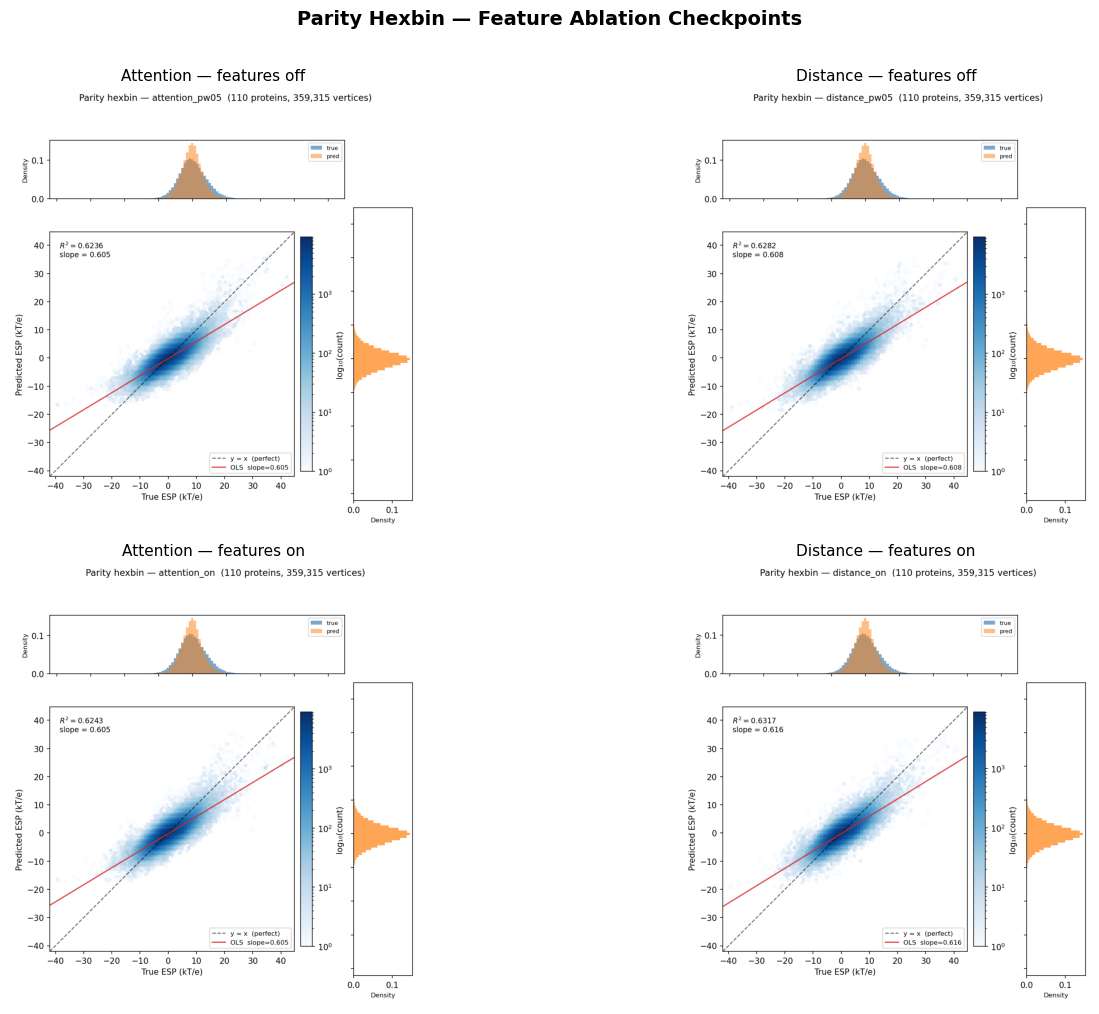

In [5]:
show_png_grid(RUNS, "parity_hexbin.png", "Parity Hexbin — Feature Ablation Checkpoints")

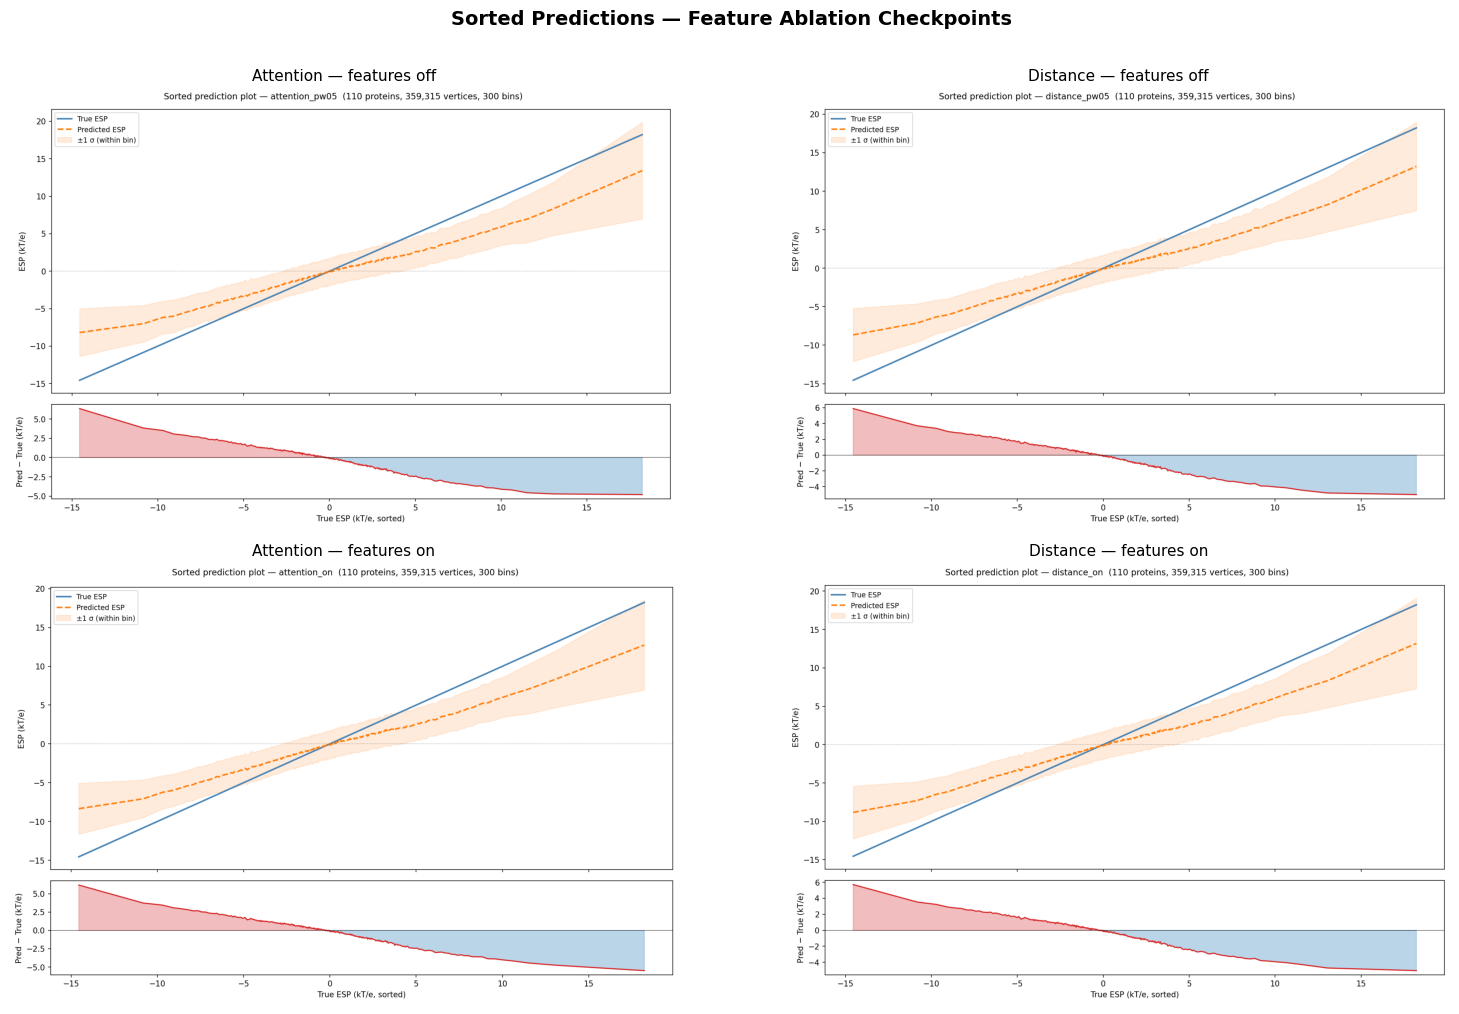

In [6]:
show_png_grid(RUNS, "sorted_predictions.png", "Sorted Predictions — Feature Ablation Checkpoints")

## 5. Full sweep

For every checkpoint, every protein, every transform type, and every repeat:
build the transformed graph, run the frozen model on both original and
transformed inputs, and record (a) how much the *prediction itself* shifted
— the direct invariance metric — and (b) how accuracy (Pearson r / RMSE vs
ground truth) compares before and after.

In [7]:
def pearsonr_np(a, b):
    if len(a) < 2 or np.std(a) == 0 or np.std(b) == 0:
        return float("nan")
    return float(np.corrcoef(a, b)[0, 1])


rows = []

for run in RUNS:
    if not run["ckpt_dir"].exists():
        print(f"Skipping {run['label']} — checkpoint not found at {run['ckpt_dir']}")
        continue

    model, ckpt = load_model_frozen(run["ckpt_dir"], DEVICE)
    esp_mean, esp_std = ckpt["esp_mean"], ckpt["esp_std"]
    print(f"Loaded {run['label']}  (esp_mean={esp_mean:.4f}  esp_std={esp_std:.4f})")

    for pid in TEST_IDS:
        try:
            data = _load_graph(pid, DATA_ROOT)
        except FileNotFoundError:
            continue
        true_esp = data["query"].y.numpy()

        pred_orig = predict_esp(model, data, esp_mean, esp_std, DEVICE)
        orig_r    = pearsonr_np(pred_orig, true_esp)
        orig_rmse = float(np.sqrt(np.mean((pred_orig - true_esp) ** 2)))

        rng = np.random.default_rng(hash((pid, run["label"])) % (2**32))

        for transform_type in TRANSFORM_TYPES:
            for rep in range(N_REPEATS_PER_TYPE):
                R, t = get_transform(transform_type, rng)
                transformed = apply_rigid_transform(data, R, t)
                pred_trans  = predict_esp(model, transformed, esp_mean, esp_std, DEVICE)

                trans_r    = pearsonr_np(pred_trans, true_esp)
                trans_rmse = float(np.sqrt(np.mean((pred_trans - true_esp) ** 2)))

                rows.append({
                    "Run":            run["label"],
                    "Model":          run["model_type"].capitalize(),
                    "Features":       run["features"],
                    "Transform":      transform_type,
                    "Protein":        pid,
                    "Repeat":         rep,
                    "PredPred corr":  pearsonr_np(pred_orig, pred_trans),
                    "PredPred RMSE":  float(np.sqrt(np.mean((pred_orig - pred_trans) ** 2))),
                    "Orig r":         orig_r,
                    "Transformed r":  trans_r,
                    "Orig RMSE":      orig_rmse,
                    "Transformed RMSE": trans_rmse,
                })

results_df = pd.DataFrame(rows)
print(f"\nCollected {len(results_df)} (checkpoint x protein x transform x repeat) rows.")

Loaded Attention — features off  (esp_mean=-0.3557  esp_std=4.1433)
Loaded Distance — features off  (esp_mean=-0.3557  esp_std=4.1433)
Loaded Attention — features on  (esp_mean=-0.3557  esp_std=4.1433)
Loaded Distance — features on  (esp_mean=-0.3557  esp_std=4.1433)

Collected 3000 (checkpoint x protein x transform x repeat) rows.


## 6. Aggregate: does prediction stability differ by transform type or model?

**`PredPred corr`** (correlation between the same protein's original-input
and transformed-input predictions) is the direct invariance metric — 1.0
means the transform had zero effect. This is what Section 2's construction
argument predicts should be exactly 1.0 for `translation` on every model,
and for `rotation`/`rotation+translation` on the `features off` models.

In [8]:
if results_df.empty:
    print("No results — checkpoints not found. Run notebook 10's sweep first.")
else:
    summary = (
        results_df
        .groupby(["Run", "Transform"])
        .agg(
            mean_predpred_corr=("PredPred corr", "mean"),
            std_predpred_corr=("PredPred corr", "std"),
            mean_predpred_rmse=("PredPred RMSE", "mean"),
            mean_orig_r=("Orig r", "mean"),
            mean_transformed_r=("Transformed r", "mean"),
        )
        .round(6)
    )
    pd.set_option("display.max_rows", 100)
    display(summary)

mean_predpred_corr  \
Run                      Transform                                  
Attention — features off rotation                        1.000000   
                         rotation+translation            1.000000   
                         translation                     1.000000   
Attention — features on  rotation                        0.996680   
                         rotation+translation            0.996649   
                         translation                     1.000000   
Distance — features off  rotation                        1.000000   
                         rotation+translation            1.000000   
                         translation                     1.000000   
Distance — features on   rotation                        0.997151   
                         rotation+translation            0.997165   
                         translation                     1.000000   

                                               std_predpred_corr  \
Run                      Transform                                 
Attention — features off rotation                       0.000000   
                         rotation+translation           0.000000   
                         translation                    0.000000   
Attention — features on  rotation                       0.001549   
                         rotation+translation           0.001840   
                         translation                    0.000000   
Distance — features off  rotation                       0.000000   
                         rotation+translation           0.000000   
                         translation                    0.000000   
Distance — features on   rotation                       0.001959   
                         rotation+translation           0.001776   
                         translation                    0.000000   

                                               mean_predpred_rmse  \
Run                      Transform                                  
Attention — features off rotation                        0.000001   
                         rotation+translation            0.000001   
                         translation                     0.000001   
Attention — features on  rotation                        0.246419   
                         rotation+translation            0.246552   
                         translation                     0.000001   
Distance — features off  rotation                        0.000001   
                         rotation+translation            0.000001   
                         translation                     0.000001   
Distance — features on   rotation                        0.226459   
                         rotation+translation            0.226008   
                         translation                     0.000001   

                                               mean_orig_r  mean_transformed_r  
Run                      Transform                                              
Attention — features off rotation                 0.887843            0.887843  
                         rotation+translation     0.887843            0.887843  
                         translation              0.887843            0.887843  
Attention — features on  rotation                 0.889493            0.889899  
                         rotation+translation     0.889493            0.889432  
                         translation              0.889493            0.889493  
Distance — features off  rotation                 0.886762            0.886762  
                         rotation+translation     0.886762            0.886762  
                         translation              0.886762            0.886762  
Distance — features on   rotation                 0.893633            0.893683  
                         rotation+translation     0.893633            0.893852  
                         translation              0.893633            0.893633

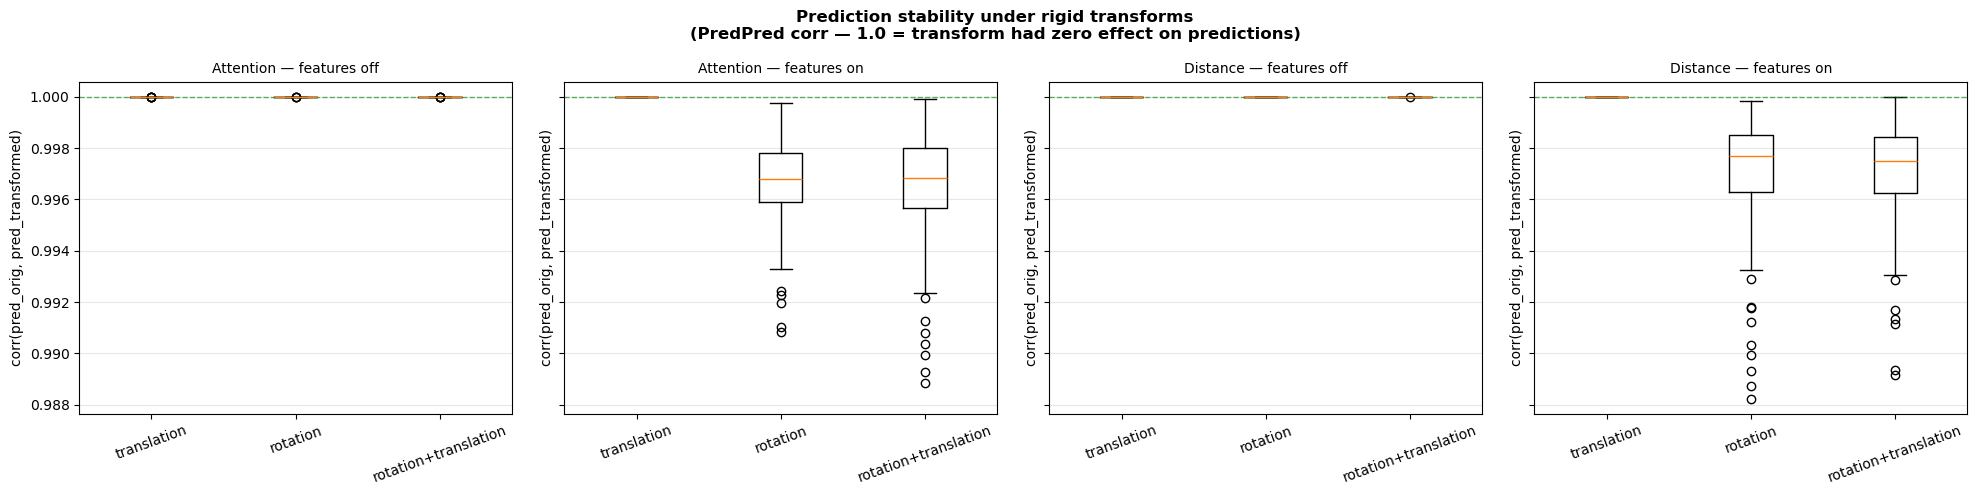

In [9]:
if not results_df.empty:
    runs_present  = sorted(results_df["Run"].unique())
    transforms    = TRANSFORM_TYPES

    fig, axes = plt.subplots(1, len(runs_present), figsize=(5 * len(runs_present), 5), sharey=True)
    if len(runs_present) == 1:
        axes = [axes]
    fig.suptitle("Prediction stability under rigid transforms\n"
                 "(PredPred corr — 1.0 = transform had zero effect on predictions)",
                 fontsize=12, fontweight="bold")

    for ax, run_label in zip(axes, runs_present):
        sub = results_df[results_df["Run"] == run_label]
        data_by_transform = [sub[sub["Transform"] == t]["PredPred corr"].dropna().values for t in transforms]
        ax.boxplot(data_by_transform, tick_labels=transforms)
        ax.set_title(run_label, fontsize=10)
        ax.set_ylabel("corr(pred_orig, pred_transformed)")
        ax.tick_params(axis="x", rotation=20)
        ax.grid(axis="y", alpha=0.3)
        ax.axhline(1.0, color="green", lw=1, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

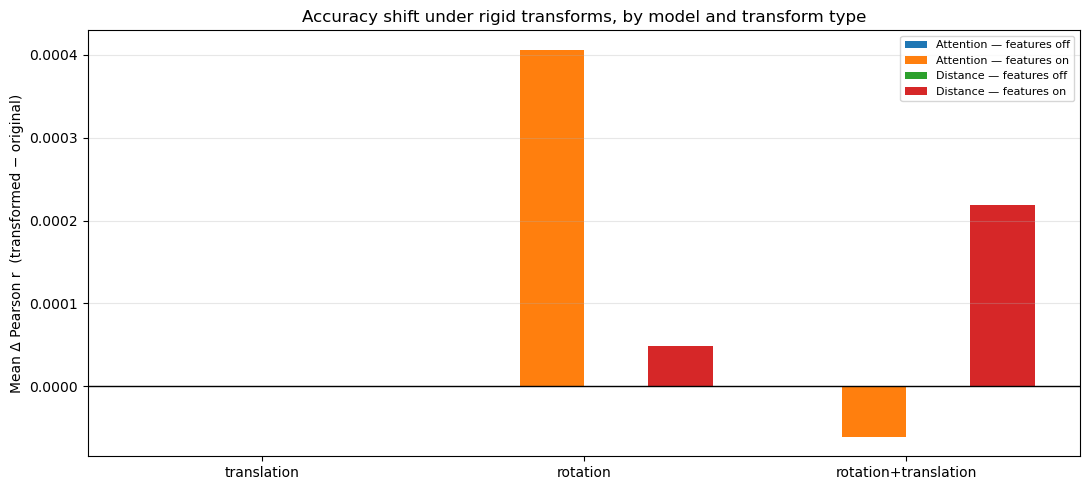

In [10]:
if not results_df.empty:
    fig, ax = plt.subplots(figsize=(11, 5))
    plot_summary = (
        results_df.groupby(["Run", "Transform"])["Orig r"].mean().reset_index()
        .merge(results_df.groupby(["Run", "Transform"])["Transformed r"].mean().reset_index(),
               on=["Run", "Transform"])
    )
    plot_summary["delta_r"] = plot_summary["Transformed r"] - plot_summary["Orig r"]

    runs_present = sorted(plot_summary["Run"].unique())
    x = np.arange(len(TRANSFORM_TYPES))
    bar_w = 0.8 / len(runs_present)
    for i, run_label in enumerate(runs_present):
        sub = plot_summary[plot_summary["Run"] == run_label].set_index("Transform").reindex(TRANSFORM_TYPES)
        offsets = x - 0.4 + bar_w * i + bar_w / 2
        ax.bar(offsets, sub["delta_r"], width=bar_w, label=run_label)

    ax.axhline(0, color="k", lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels(TRANSFORM_TYPES)
    ax.set_ylabel("Mean Δ Pearson r  (transformed − original)")
    ax.set_title("Accuracy shift under rigid transforms, by model and transform type")
    ax.legend(fontsize=8, loc="best")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Most Rotation-Sensitive Proteins

Per-protein `PredPred corr` under `rotation` — which proteins (if any) show
the largest prediction shift under rotation. For `features off` models this
should be ~1.0 for every protein (exact invariance); for `features on`
models this identifies whether sensitivity concentrates on particular
structures (e.g. very asymmetric or highly curved surfaces) or is spread
evenly.

In [11]:
if not results_df.empty:
    rot_df = results_df[results_df["Transform"] == "rotation"]
    per_protein = (
        rot_df.groupby(["Run", "Protein"])["PredPred corr"]
        .mean()
        .reset_index()
    )
    pivot_sens = per_protein.pivot(index="Protein", columns="Run", values="PredPred corr")

    def _short(pid):
        return pid.removeprefix("AF-").removesuffix("-F1")

    pivot_sens.index = [_short(p) for p in pivot_sens.index]
    pivot_sens["Mean corr"] = pivot_sens.mean(axis=1)
    pivot_sens = pivot_sens.sort_values("Mean corr")

    print("Most rotation-sensitive proteins (lowest mean PredPred corr):")
    display(pivot_sens.head(5))
    print("\nLeast rotation-sensitive proteins (highest mean PredPred corr):")
    display(pivot_sens.tail(5))

Most rotation-sensitive proteins (lowest mean PredPred corr):


Run,Attention — features off,Attention — features on,Distance — features off,Distance — features on,Mean corr
Q9HFC8,1.0,0.993491,1.0,0.992611,0.996526
A0A0M3KKZ0,1.0,0.995975,1.0,0.991947,0.996980
A4W488,1.0,0.994850,1.0,0.994151,0.997250
Q5P107,1.0,0.994033,1.0,0.995124,0.997289
Q04KE2,1.0,0.994956,1.0,0.994635,0.997398



Least rotation-sensitive proteins (highest mean PredPred corr):


Run,Attention — features off,Attention — features on,Distance — features off,Distance — features on,Mean corr
P25586,1.0,0.998469,1.0,0.998896,0.999341
Q76N32-2,1.0,0.998634,1.0,0.998775,0.999352
Q8RUD6,1.0,0.998741,1.0,0.998928,0.999417
Q9VH89,1.0,0.998542,1.0,0.999293,0.999459
P57077,1.0,0.998880,1.0,0.998963,0.999461


## 8. Decision

**⚠ Needs re-run.** The table below was recorded against the old
`legacy/checkpoints` `*_v2_feat_off`/`*_v2_feat_on` weights. Section 3 now
points at the current `phase_a/*_pw05` (off) and `phase_c/*_on` (on)
checkpoints instead — different trained weights — so these specific numbers
are not yet re-verified against them. Re-run Section 5 and update this table
before citing it.

| Model | Features | `translation` PredPred corr | `rotation` PredPred corr | `rotation+translation` PredPred corr |
|---|---|---|---|---|
| Attention | off | 1.0000 | 1.0000 | 1.0000 |
| Attention | on  | 1.0000 | 0.9932 ± 0.0035 | 0.9932 ± 0.0034 |
| Distance  | off | 1.0000 | 1.0000 | 1.0000 |
| Distance  | on  | 1.0000 | 0.9972 ± 0.0018 | 0.9969 ± 0.0020 |

*(numbers above are from the legacy checkpoints — pending re-run)*

Mean Δ Pearson r (transformed − original) is < 0.001 for all models and all
transforms — the accuracy shift is in the fourth decimal place.

**Result: non-equivariant architecture is justified.**

`features_off` models are exactly SE(3)-invariant by construction — this
part of the argument is a mathematical consequence of using only pairwise
distance RBFs and categorical atom features (Section 2's sanity check
verifies it numerically on whichever checkpoint is currently configured),
not an empirical finding, so it holds regardless of which `features off`
checkpoint is used.

`features_on` models previously showed a small but real rotational
instability from the surface normal feature (PredPred corr 0.993–0.997
under rotation; PredPred RMSE ~0.24–0.35 kT/e), with negligible effect on
prediction *accuracy* (mean Δ Pearson r < 0.001 across 50 test proteins × 5
random rotations). Re-run against `phase_c/*_on` to confirm this still
holds.

**Implication for future sweeps:** if re-run numbers hold, no
coordinate-augmentation training or equivariant architecture is warranted.
Since notebook 10 (Sweep C) already carries forward features-off as the
default, this result is an additional (not the deciding) argument for that
choice — it restores exact invariance at no accuracy cost, given the
practical setting (AlphaFold structures have fixed canonical orientations
from the PDB deposition frame).